In [2]:
from ref import *
from read_complex_matrix import read_complex_matrix
matr = read_complex_matrix('ref_matrix.txt')
import timeit

In [3]:
%%time

x_crit, x_max, y_max, x_min, y_min = reflectometry_trace(matr[1,2], matr[1,0], matr[2,2], matr[2,0])

CPU times: total: 0 ns
Wall time: 4 ms


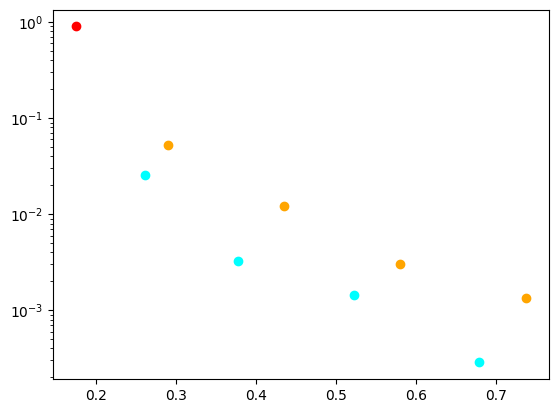

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

#ax.plot(q[0:len(y)]*1e-9, y)
ax.scatter(x_max*1e-9, y_max, color = 'orange')
ax.scatter(x_min*1e-9, y_min, color = 'cyan')
ax.scatter(x_crit*1e-9, 0.9, color = 'red')

ax.set_yscale('log')

plt.show()

In [5]:
def loss_function(crit1, r_max1, q_max1, r_min1, q_min1, crit2, r_max2, q_max2, r_min2, q_min2):
    #r_min могут плохо сходиться в случаях со свёрткой, т.к. она их завышает на порядок
    return (2*(crit1-crit2)/crit1)**2 + np.sum(((r_max1-r_max2)/r_max1)**2) + np.sum(((q_max1-q_max2)/q_max1)**2) + np.sum(((q_min1-q_min2)/q_min1)**2)

In [6]:
def objective_function(params):
    rough1, len1, rough2, len2 = params
    crit1, r_max1, q_max1, r_min1, q_min1 = reflectometry_trace(matr[1,2], matr[1,0], matr[2,2], matr[2,0])
    crit2, r_max2, q_max2, r_min2, q_min2 = reflectometry_trace(rough1, len1, rough2, len2)
    return 1e+6*loss_function(crit1, r_max1, q_max1, r_min1, q_min1, crit2, r_max2, q_max2, r_min2, q_min2)

In [7]:
from scipy.optimize import differential_evolution as de
from scipy.optimize import minimize


# диапазон для шероховатостей и глубин (для двух поверхностных слоёв)
bounds = [[0, 8e-9], [3.e-08, 5.e-08],
          [0, 8e-9], [1.4e-8, 2.6e-8]]

initial_guess = [1e-9, 3.1e-08, 1e-9, 1.5e-8]

In [8]:
%%time

# Оптимизация с симплекс-методом
result = minimize(
    objective_function,
    initial_guess,
    method='Nelder-Mead',  
    bounds=bounds
)

CPU times: total: 2.7 s
Wall time: 2.71 s


In [9]:
result

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.268552774167673e-05
             x: [ 4.000e-09  4.000e-08  2.000e-09  2.000e-08]
           nit: 320
          nfev: 534
 final_simplex: (array([[ 4.000e-09,  4.000e-08,  2.000e-09,  2.000e-08],
                       [ 4.000e-09,  4.000e-08,  2.000e-09,  2.000e-08],
                       ...,
                       [ 4.000e-09,  4.000e-08,  2.000e-09,  2.000e-08],
                       [ 4.000e-09,  4.000e-08,  2.000e-09,  2.000e-08]],
                      shape=(5, 4)), array([ 5.269e-05,  6.881e-05,  1.125e-04,  1.263e-04,
                        1.467e-04]))

In [31]:
%%time

# Оптимизация с автоматическим численным градиентом вариант 1
result = minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',  
    bounds=bounds,
    options={
        'eps': 1e-15, # Шаг для численного градиента
        'maxfun': 1e+8,
        'ftol': 2e-17, 
        'gtol': 1e-20
    }  
)

CPU times: total: 2.89 s
Wall time: 2.89 s


In [33]:
result

  message: ABNORMAL: 
  success: False
   status: 2
      fun: 6.8589373656499e-06
        x: [ 4.000e-09  4.000e-08  2.000e-09  2.000e-08]
      nit: 38
      jac: [ 1.618e+04  3.919e+04  5.061e+04 -3.776e+04]
     nfev: 610
     njev: 122
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [35]:
%%time

# Оптимизация с автоматическим численным градиентом вариант 2
result = minimize(
    objective_function,
    initial_guess,
    method='TNC',  
    bounds=bounds,
    options={
        'eps': 1e-15, # Шаг для численного градиента
        'maxfun': 1e+8,
        'ftol': 2e-17, 
        'xtol': 1e-20,
        'gtol': 1e-20
            }
)

CPU times: total: 7.38 s
Wall time: 7.38 s


In [37]:
result

 message: Linear search failed
 success: False
  status: 4
     fun: 1.4495014224665394e-05
       x: [ 4.000e-09  4.000e-08  2.000e-09  2.000e-08]
     nit: 56
     jac: [-1.778e+08  1.822e+08  4.468e+07  7.235e+07]
    nfev: 1585